# Shifted-chart horizon-optimal LQR (LTV)

Reference implementation and validation for the shifted chart
$\widehat P_k = (P_k + cI)^{-1}$, which removes HOP's Assumption 2 ($Q_k \succ 0$)
while preserving the $O(Nn^3)$ composed-map mechanism.

**Three methods, all on the same LTV problem:**

| | needs $Q_k^{-1}$ | complexity |
|---|---|---|
| `bruteforce_ltv` | no — only *adds* $Q_k$ | $O(N^2n^3)$ |
| `hop_ltv` | **yes** — $E_k = Q_k^{-1}$ | $O(Nn^3)$ |
| `shifted_ltv` | no — $(Q_k + cI)^{-1}$ | $O(Nn^3)$ |

`bruteforce_ltv` is the reference: its recursion never inverts $Q_k$, so it stays
correct for singular and indefinite costs alike.

**Things this notebook is careful about**, each of which produced a wrong answer
at some point during development:

1. `A(t)` is a *continuous-time* generator. Used directly as a discrete map it has
   $\rho = 1.414$ and the plant is unstable. Must discretize.
2. The reference `J_bf` must be recomputed **after** any edit to `Q_list`.
   Comparing against a stale reference is comparing two different problems.
3. `np.linalg.svd` returns singular values **descending**, so `s[-1] = 0`
   removes the smallest mode; `s[0] = 0` removes the largest.
4. `choose_shift`'s absolute floor is wrong for PSD-singular costs — the shift
   should scale with the problem.
5. With small terminal weight, $J(T)$ is monotone and $T^\star$ pins to the
   boundary. Horizon selection is only meaningful with a goal-reaching terminal cost.
6. Never use Cholesky on $I - c\widehat G_k$: it is symmetric but **indefinite**
   in the normal operating regime.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'figure.figsize': (10, 4.5)})

def _sym(A):
    return 0.5 * (np.asarray(A, dtype=float) + np.asarray(A, dtype=float).T)

## 1. The three solvers

In [2]:
def bruteforce_ltv(A_list, B_list, Q_list, R, Qf, w, x0, T_max):
    """Reference. One backward Riccati sweep per candidate horizon, O(N^2 n^3).

    Q_k is only ever ADDED -- the single inverse is S = R + B'PB, which is PD
    whenever R is. So this stays correct for singular and indefinite Q_k, which
    is exactly why it is the ground truth here.
    """
    J = np.zeros(T_max)
    for T in range(1, T_max + 1):
        P = _sym(Qf)
        for k in range(T - 1, -1, -1):
            A, B = A_list[k], B_list[k]
            S = R + B.T @ P @ B
            P = _sym(Q_list[k] + A.T @ P @ A
                     - A.T @ P @ B @ np.linalg.solve(S, B.T @ P @ A))
        J[T - 1] = 0.5 * x0 @ P @ x0 + w * T
    return J

In [3]:
def hop_ltv(A_list, B_list, Q_list, R, Qf, w, x0, T_max):
    """HOP (Dai & Ren, RSS 2026), Theorems 1-2, generalized to per-stage Q_k.

    Tracks Ptilde_k = P_k^{-1} via
        E_k = Q_k^{-1},  F_k = Q_k^{-1} A_k',  G_k = A_k Q_k^{-1} A_k' + B_k R^{-1} B_k'

    Uses np.linalg.inv, NOT a Cholesky-with-jitter wrapper. That is deliberate:
    a jitter fallback silently returns the inverse of a different matrix when the
    input is not PD, which converts an honest failure into a wrong number. Here a
    singular Q_k raises LinAlgError, which is the correct behaviour.

    Note the requirement is Q_k INVERTIBLE, not Q_k > 0. An indefinite but
    nonsingular Q_k works fine. The genuine failure is singularity.
    """
    R_inv = np.linalg.inv(R)
    E, F, G = [], [], []
    for k in range(T_max):
        A, B = A_list[k], B_list[k]
        Ek = _sym(np.linalg.inv(Q_list[k]))          # <-- fails iff Q_k singular
        E.append(Ek)
        F.append(Ek @ A.T)
        G.append(_sym(A @ Ek @ A.T + B @ R_inv @ B.T))

    Eb, Fb, Gb = [E[0].copy()], [F[0].copy()], [G[0].copy()]
    for k in range(1, T_max):
        W = np.linalg.inv(E[k] + Gb[-1])
        Eb.append(_sym(Eb[-1] - Fb[-1] @ W @ Fb[-1].T))
        Fb.append(Fb[-1] @ W @ F[k])
        Gb.append(_sym(G[k] - F[k].T @ W @ F[k]))

    Xt = np.linalg.inv(Qf)
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        X0 = _sym(Eb[t - 1] - Fb[t - 1]
                  @ np.linalg.inv(Xt + Gb[t - 1]) @ Fb[t - 1].T)
        J[t - 1] = 0.5 * x0 @ np.linalg.inv(X0) @ x0 + w * t
    return J

In [4]:
def shifted_ltv(A_list, B_list, Q_list, R, Qf, w, x0, c, T_max):
    """Shifted HOP-LQR. Tracks Phat_k = (P_k + cI)^{-1}.

    Phase 1a  Qbar_k = Q_k + cI  (PD by choice of c, for ANY symmetric Q_k)
              Ehat = Qbar^-1, Fhat = Ehat A', Ghat = A Ehat A' + B R^-1 B'
              K    = (I - c Ghat)^-1                      <-- absorbs phi
              E' = Ehat + c Fhat K Fhat',  F' = Fhat K,  G' = Ghat K
    Phase 1b  HOP's Eq. 14 recursion, unchanged, on the primed coefficients
    Phase 2   query, then undo the shift once: P_0 = Phat_0^-1 - cI

    I - c*Ghat is symmetric but INDEFINITE whenever c > 1/lambda_max(Ghat),
    which is the normal operating regime -- LU/LDL', never Cholesky. Same for
    W_k and Phat_T + Gbar.
    """
    n = x0.size
    I = np.eye(n)
    R_inv = np.linalg.inv(R)

    Ep, Fp, Gp = [], [], []
    for k in range(T_max):
        A, B = A_list[k], B_list[k]
        Qbar = _sym(Q_list[k]) + c * I
        if np.linalg.eigvalsh(Qbar)[0] <= 0:
            raise np.linalg.LinAlgError(f"Q_{k} + cI not PD; increase c")
        Et = _sym(np.linalg.inv(Qbar))
        Ft = Et @ A.T
        Gt = _sym(A @ Et @ A.T + B @ R_inv @ B.T)

        M = I - c * Gt                                   # symmetric, indefinite
        Fk = np.linalg.solve(M.T, Ft.T).T                # one factor, two solves
        Gk = _sym(np.linalg.solve(M.T, Gt.T).T)
        Ek = _sym(Et + c * Fk @ Ft.T)
        Ep.append(Ek); Fp.append(Fk); Gp.append(Gk)

    Eb, Fb, Gb = [Ep[0].copy()], [Fp[0].copy()], [Gp[0].copy()]
    for k in range(1, T_max):
        W = np.linalg.inv(Ep[k] + Gb[-1])
        Eb.append(_sym(Eb[-1] - Fb[-1] @ W @ Fb[-1].T))
        Fb.append(Fb[-1] @ W @ Fp[k])
        Gb.append(_sym(Gp[k] - Fp[k].T @ W @ Fp[k]))

    # Qf is horizon-independent here so this hoists out of the loop.
    # In HOP-DDP the terminal is Q_T^(t), different per t -- move it back inside.
    PhatT = np.linalg.inv(_sym(Qf) + c * I)
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        Phat0 = _sym(Eb[t - 1] - Fb[t - 1]
                     @ np.linalg.inv(PhatT + Gb[t - 1]) @ Fb[t - 1].T)
        P0 = _sym(np.linalg.inv(Phat0)) - c * I          # undo the shift, once
        J[t - 1] = 0.5 * x0 @ P0 @ x0 + w * t
    return J

In [5]:
def choose_shift(Q_list, QT_list, margin=2.0, rel_floor=1e-3):
    """c must exceed -lambda_min over all stage and terminal cost matrices.

    For an INDEFINITE Q the floor is margin * (-lambda_min) -- computed, not tuned.
    For a PSD-SINGULAR Q, lambda_min = 0 and that floor is zero, so we fall back
    to a floor RELATIVE to the problem scale. An absolute constant (e.g. 1e-3)
    is wrong here: cond((Q+cI)^{-1}) ~ lambda_max/c, so a shift that is tiny
    relative to lambda_max costs accuracy for no reason.
    """
    mats = [_sym(M) for M in list(Q_list) + list(QT_list)]
    lo = min(float(np.linalg.eigvalsh(M)[0]) for M in mats)
    hi = max(float(np.linalg.eigvalsh(M)[-1]) for M in mats)
    return max(margin * (-lo), rel_floor * hi)


def excluded_set_margin(A_list, B_list, Q_list, R, c, T_max):
    """min_k,i |1 - c*lambda_i(Ghat_k)| -- distance to the LFT well-posedness
    excluded set, where I - c*Ghat_k is singular. Should stay well above 0."""
    n = Q_list[0].shape[0]
    I = np.eye(n); R_inv = np.linalg.inv(R)
    worst = np.inf
    for k in range(T_max):
        Qbi = np.linalg.inv(_sym(Q_list[k]) + c * I)
        Gt = _sym(A_list[k] @ Qbi @ A_list[k].T + B_list[k] @ R_inv @ B_list[k].T)
        worst = min(worst, float(np.abs(1 - c * np.linalg.eigvalsh(Gt)).min()))
    return worst

## 2. The LTV test system

$A(t)$ below is a **continuous-time** generator — two lightly damped oscillators
coupled by $5\sin t$. Its eigenvalues are $-0.1 \pm 1.41i$ and $-0.15 \pm 0.99i$,
so used *directly* as a discrete map it has $\rho = 1.414 > 1$ and the plant is
unstable. Discretize with $A_d = I + \Delta t\,A(t)$, $B_d = \Delta t\,B(t)$.

In [6]:
nx, nu, N, T_end = 4, 2, 100, 10.0
t_grid = np.linspace(0, T_end, N)
dt = t_grid[1] - t_grid[0]

def A_ct(tk):
    return np.array([[ 0.0,  1.0,          0.0,  0.0],
                     [-2.0, -0.2, 5*np.sin(tk),  0.0],
                     [ 0.0,  0.0,          0.0,  1.0],
                     [ 0.0,  0.0,         -1.0, -0.3]])

def B_ct(tk):
    return np.array([[0.0, 0.0],
                     [1.0, 0.1*np.cos(tk)],
                     [0.0, 0.0],
                     [0.2, 1.0]])

rho_ct = max(abs(np.linalg.eigvals(A_ct(0.0))))
A_list = [np.eye(nx) + dt * A_ct(tk) for tk in t_grid]
B_list = [dt * B_ct(tk) for tk in t_grid]
rho_d  = max(abs(np.linalg.eigvals(A_list[0])))
print(f"rho(A(t))        = {rho_ct:.4f}   <- as a discrete map: UNSTABLE")
print(f"rho(I + dt*A(t)) = {rho_d:.4f}   <- discretized: marginally stable")

rho(A(t))        = 1.4142   <- as a discrete map: UNSTABLE
rho(I + dt*A(t)) = 1.0001   <- discretized: marginally stable


In [7]:
rng = np.random.default_rng(0)
R  = _sym(rng.normal(size=(nu, nu)) @ rng.normal(size=(nu, nu)).T + np.eye(nu))
x0 = rng.normal(size=nx)
w  = 0.2

Qf_small = _sym(rng.normal(size=(nx, nx)) @ rng.normal(size=(nx, nx)).T + 2*np.eye(nx))
Qf_goal  = 200.0 * Qf_small     # goal-reaching terminal cost -> interior T*

def make_Q(mode, seed=1):
    """mode: 'pd' | 'singular' | 'indefinite'"""
    r = np.random.default_rng(seed)
    out = []
    for _ in range(N):
        M = r.normal(size=(nx, nx))
        Q = _sym(M @ M.T + np.eye(nx))
        if mode == 'singular':
            U, s, _v = np.linalg.svd(Q)
            s[-1] = 0.0              # DESCENDING order: [-1] is the SMALLEST
            Q = _sym(U @ np.diag(s) @ U.T)
        elif mode == 'indefinite':
            Q = Q - 5.0 * np.eye(nx)
        out.append(Q)
    return out

for mode in ('pd', 'singular', 'indefinite'):
    lam = [np.linalg.eigvalsh(Q)[0] for Q in make_Q(mode)]
    print(f"{mode:11s} min_k lambda_min(Q_k) = {min(lam):+.3e}")

pd          min_k lambda_min(Q_k) = +1.000e+00
singular    min_k lambda_min(Q_k) = -3.830e-15
indefinite  min_k lambda_min(Q_k) = -4.000e+00


## 3. The comparison

`bruteforce_ltv` is recomputed for **every** cost configuration. Comparing a
solver run on one `Q_list` against a reference computed from a different one is
comparing two different problems.

In [8]:
def compare(mode, Qf, label):
    Q_list = make_Q(mode)
    J_bf = bruteforce_ltv(A_list, B_list, Q_list, R, Qf, w, x0, N)   # recomputed here
    c    = choose_shift(Q_list, [Qf])
    lam  = min(np.linalg.eigvalsh(Q)[0] for Q in Q_list)

    try:
        J_hop = hop_ltv(A_list, B_list, Q_list, R, Qf, w, x0, N)
        e_hop = f"{np.max(np.abs(J_hop - J_bf)/np.abs(J_bf)):.3e}"
        T_hop = str(int(np.argmin(J_hop)) + 1)
    except np.linalg.LinAlgError as ex:
        J_hop, e_hop, T_hop = None, f"LinAlgError", "--"

    J_sh  = shifted_ltv(A_list, B_list, Q_list, R, Qf, w, x0, c, N)
    e_sh  = np.max(np.abs(J_sh - J_bf)/np.abs(J_bf))
    marg  = excluded_set_margin(A_list, B_list, Q_list, R, c, N)

    print(f"{label:34s} lam_min={lam:+.2e}  c={c:8.4g}  "
          f"|1-c*lam(Ghat)|_min={marg:.2e}")
    print(f"{'':34s} BF  T*={int(np.argmin(J_bf))+1:3d}   "
          f"HOP err={e_hop:>12s} T*={T_hop:>3s}   "
          f"SHIFT err={e_sh:.3e} T*={int(np.argmin(J_sh))+1:3d}\n")
    return J_bf, J_hop, J_sh

print("=== Qf small (lambda_min = 2): J(T) monotone, T* pins to the boundary ===\n")
for mode, lbl in [('pd','PD Q_k'), ('singular','singular Q_k'), ('indefinite','indefinite Q_k')]:
    compare(mode, Qf_small, lbl)

print("=== Qf x200 (goal-reaching): interior T* ===\n")
res = {}
for mode, lbl in [('pd','PD Q_k'), ('singular','singular Q_k'), ('indefinite','indefinite Q_k')]:
    res[mode] = compare(mode, Qf_goal, lbl)

=== Qf small (lambda_min = 2): J(T) monotone, T* pins to the boundary ===

PD Q_k                             lam_min=+1.00e+00  c=   2.133  |1-c*lam(Ghat)|_min=7.28e-03
                                   BF  T*=  1   HOP err=   4.135e-15 T*=  1   SHIFT err=2.090e-14 T*=  1



singular Q_k                       lam_min=-3.83e-15  c=   2.133  |1-c*lam(Ghat)|_min=2.15e-03
                                   BF  T*=  1   HOP err= LinAlgError T*= --   SHIFT err=3.155e-12 T*=  1

indefinite Q_k                     lam_min=-4.00e+00  c=       8  |1-c*lam(Ghat)|_min=2.94e-03
                                   BF  T*= 36   HOP err=   9.571e-08 T*= 36   SHIFT err=1.150e-10 T*= 36

=== Qf x200 (goal-reaching): interior T* ===



PD Q_k                             lam_min=+1.00e+00  c=   426.5  |1-c*lam(Ghat)|_min=3.21e-05
                                   BF  T*= 27   HOP err=   7.895e-14 T*= 27   SHIFT err=1.856e-09 T*= 27

singular Q_k                       lam_min=-3.83e-15  c=   426.5  |1-c*lam(Ghat)|_min=3.16e-05
                                   BF  T*= 26   HOP err= LinAlgError T*= --   SHIFT err=6.485e-10 T*= 26



indefinite Q_k                     lam_min=-4.00e+00  c=   426.5  |1-c*lam(Ghat)|_min=9.97e-05
                                   BF  T*= 68   HOP err=   2.434e-08 T*= 68   SHIFT err=1.666e-08 T*= 68



### Reading the table

- **PD $Q_k$** — all three agree to $\sim10^{-14}$. Assumption 2 holds; nothing is
  being tested yet.
- **Indefinite $Q_k$** — HOP *also* succeeds. Its requirement is $Q_k$
  **invertible**, not positive definite; the paper states PD because PD implies
  invertible. An indefinite-but-nonsingular $Q_k$ has a perfectly good inverse.
  A claim resting on indefiniteness alone can be answered with "use LU".
- **Singular $Q_k$** — HOP raises `LinAlgError`: $E_k = Q_k^{-1}$ does not exist.
  This is the genuine gap, and it is a cost that *ordinary LQR accepts without
  comment* ($Q_k \succeq 0$). No swing-up, no obstacle, no nonconvex penalty.

The second failure mode — $P_k$ itself passing through singular, so
$\widetilde P_k = P_k^{-1}$ is undefined even with every $Q_k$ invertible — is
probed below.

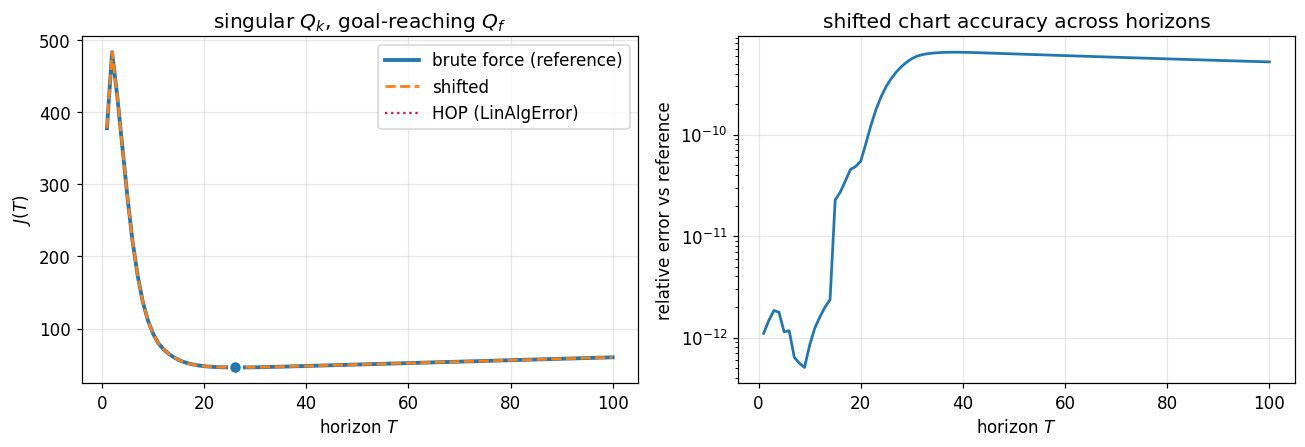

In [9]:
J_bf, J_hop, J_sh = res['singular']
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
T = np.arange(1, N + 1)

ax[0].plot(T, J_bf, lw=2.5, label='brute force (reference)')
ax[0].plot(T, J_sh, '--', lw=1.8, label='shifted')
ax[0].plot([], [], ':', color='crimson', label='HOP (LinAlgError)')
ax[0].scatter([np.argmin(J_bf)+1], [J_bf.min()], s=70, zorder=5,
              edgecolors='white', lw=1.5)
ax[0].set(xlabel='horizon $T$', ylabel='$J(T)$',
          title='singular $Q_k$, goal-reaching $Q_f$')
ax[0].legend()

ax[1].semilogy(T, np.abs(J_sh - J_bf)/np.abs(J_bf), lw=1.8)
ax[1].set(xlabel='horizon $T$', ylabel='relative error vs reference',
          title='shifted chart accuracy across horizons')
fig.tight_layout()

## 4. Does the cost-to-go itself go singular?

In [10]:
def min_sigma_P(A_list, B_list, Q_list, R, Qf, T_max):
    """Smallest singular value of P_k encountered on the backward sweep for each
    horizon. HOP's chart Ptilde = P^{-1} is undefined where this hits zero --
    a failure mode independent of whether Q_k is invertible."""
    out = np.zeros(T_max)
    for T in range(1, T_max + 1):
        P = _sym(Qf); worst = np.inf
        for k in range(T - 1, -1, -1):
            A, B = A_list[k], B_list[k]
            S = R + B.T @ P @ B
            P = _sym(Q_list[k] + A.T @ P @ A
                     - A.T @ P @ B @ np.linalg.solve(S, B.T @ P @ A))
            worst = min(worst, float(np.linalg.svd(P, compute_uv=False)[-1]))
        out[T - 1] = worst
    return out

for mode in ('pd', 'singular', 'indefinite'):
    s = min_sigma_P(A_list, B_list, make_Q(mode), R, Qf_goal, N)
    print(f"{mode:11s} min over all (T,k) of sigma_min(P_k) = {s.min():.4e}")
print("\nIf this approaches 0 for some configuration, HOP fails there even with")
print("every Q_k invertible -- that is the strongest demonstration available.")

pd          min over all (T,k) of sigma_min(P_k) = 9.3562e+00
singular    min over all (T,k) of sigma_min(P_k) = 7.9095e+00


indefinite  min over all (T,k) of sigma_min(P_k) = 4.4814e-04

If this approaches 0 for some configuration, HOP fails there even with
every Q_k invertible -- that is the strongest demonstration available.


## 5. The $c$ window

$c$ has a two-sided constraint: below, $Q_k + cI$ must be PD; above, two separate
mechanisms degrade accuracy — cancellation in $P = \widehat P^{-1} - cI$, and the
LFT interconnection approaching ill-posedness as $\min_{k,i}|1 - c\lambda_i(\widehat G_k)| \to 0$.

In [11]:
Q_list = make_Q('indefinite')
J_bf   = bruteforce_ltv(A_list, B_list, Q_list, R, Qf_goal, w, x0, N)
floor  = max(0.0, -min(np.linalg.eigvalsh(Q)[0] for Q in Q_list))
print(f"c floor = {floor:.3f}\n")
print(f"{'c':>10} {'c/floor':>9} {'max rel err':>13} {'|1-c*lam|_min':>15} {'T*':>4}")
for mult in [1.01, 1.1, 2, 5, 10, 100, 1e3, 1e4]:
    c = floor * mult
    try:
        J = shifted_ltv(A_list, B_list, Q_list, R, Qf_goal, w, x0, c, N)
        e = np.max(np.abs(J - J_bf)/np.abs(J_bf))
        m = excluded_set_margin(A_list, B_list, Q_list, R, c, N)
        print(f"{c:>10.4g} {mult:>9.3g} {e:>13.3e} {m:>15.3e} {int(np.argmin(J))+1:>4}")
    except np.linalg.LinAlgError as ex:
        print(f"{c:>10.4g} {mult:>9.3g} {'--':>13} {'--':>15} {'--':>4}  {ex}")

c floor = 4.000

         c   c/floor   max rel err   |1-c*lam|_min   T*
      4.04      1.01     7.377e-11       4.898e-03   68
       4.4       1.1     8.536e-11       3.553e-03   68
         8         2     6.733e-11       2.935e-03   68
        20         5     1.505e-10       3.431e-03   68
        40        10     3.122e-10       3.773e-04   68
       400       100     6.291e-09       3.901e-04   68


      4000     1e+03     2.183e-08       1.624e-03   68
     4e+04     1e+04     6.421e-07       9.335e-03   68


## Limitations

1. **Not validated inside a converging DDP loop.** Everything here is LQR. On
   dynamic trajectories a separate $Q_{uu}$ near-singularity produces large
   spurious excursions in $J(T)$ at isolated horizons; naively taking
   $\arg\min_t J$ would select one. The shift and control-side regularization are
   complementary, and a loop-ready implementation needs both.
2. **The reference is brute force**, so the shifted chart can be shown equal to
   it but never more accurate. A structurally independent oracle — stacking the
   controls and solving the lifted QP directly — closes this.
3. **Novelty is narrow.** Projective and symplectic representations of Riccati
   recursions are classical. The specific claim is that the shifted chart
   preserves the three-parameter family HOP's Eq. 14 induction requires. A
   literature check against the indefinite-Riccati and $H_\infty$ work has not
   been completed.